<a href="https://colab.research.google.com/github/tamiresvferreira/tamiresvferreira/blob/main/Classifica%C3%A7%C3%A3o_de_Sementes_Vfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Classificação de Grãos de Trigo com Machine Learning
### Metodologia CRISP-DM aplicada ao Seeds Dataset (UCI Machine Learning Repository)

---

## Objetivo

Este trabalho tem como objetivo desenvolver e avaliar modelos de aprendizado de máquina capazes de classificar automaticamente três variedades de grãos de trigo: **Kama**, **Rosa** e **Canadian**, com base em suas características físicas mensuráveis.

A metodologia adotada é o **CRISP-DM** (Cross-Industry Standard Process for Data Mining), que organiza o trabalho em fases iterativas: compreensão dos dados → preparação → modelagem → avaliação → interpretação.

---
## 📦 0. Configuração do Ambiente

Antes de qualquer análise, importamos todas as bibliotecas necessárias e definimos configurações globais.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='Set2')
SEED = 42

print('✅ Ambiente configurado com sucesso.')

✅ Ambiente configurado com sucesso.


---
## 📊 Fase 1 — Compreensão e Pré-processamento dos Dados

### 1.1 Carregamento dos Dados

O dataset não possui cabeçalho — as colunas são nomeadas manualmente conforme a documentação do UCI. Um detalhe importante: o arquivo original contém **separadores irregulares** em algumas linhas (tabs duplos), o que causa falha no parsing com `sep='\t'`. A solução é usar `sep=r'\s+'`, que interpreta qualquer sequência de espaços em branco como separador — comportamento mais robusto para arquivos de dados científicos.

A coluna `variedade_nome` é criada como rótulo textual para facilitar a leitura dos gráficos, mas o modelo usará os valores numéricos originais (1, 2, 3) como variável alvo.

In [ ]:
colunas = [
    'area', 'perimetro', 'compacidade',
    'comprimento_nucleo', 'largura_nucleo',
    'coef_assimetria', 'comprimento_sulco', 'variedade'
]

df = pd.read_csv(
    'seeds_dataset.txt',
    sep=r'\s+',
    header=None,
    names=colunas,
    engine='python'
)

mapa = {1: 'Kama', 2: 'Rosa', 3: 'Canadian'}
df['variedade_nome'] = df['variedade'].map(mapa)

print(f'Shape do dataset: {df.shape}')
print(f'\nDistribuição das classes:')
print(df['variedade_nome'].value_counts())
print()
df.head()

Shape do dataset: (210, 9)

Distribuição das classes:
variedade_nome
Kama        70
Rosa        70
Canadian    70
Name: count, dtype: int64



,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coef_assimetria,comprimento_sulco,variedade,variedade_nome
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,Kama


### 1.2 Estatísticas Descritivas

As estatísticas descritivas revelam dois aspectos fundamentais que orientarão as decisões de pré-processamento:

1. **Diferença de escala entre features**: `area` tem média ~14.85, enquanto `compacidade` tem média ~0.87. Essa diferença de ordem de grandeza é irrelevante para o Random Forest (que usa comparações binárias), mas é crítica para KNN, SVM e Regressão Logística, que trabalham com distâncias ou combinações lineares dos valores.

2. **Variabilidade do coeficiente de assimetria**: o maior desvio padrão relativo entre as features, sugerindo que essa característica apresenta maior dispersão entre os grãos — o que pode ser informativo para a classificação.

In [ ]:
features = colunas[:-1]

desc = df[features].agg(['mean', 'median', 'std', 'min', 'max']).T
desc.columns = ['Média', 'Mediana', 'Desvio Padrão', 'Mínimo', 'Máximo']
desc.round(4)

,Média,Mediana,Desvio Padrão,Mínimo,Máximo
area,14.8475,14.3550,2.9097,10.5900,21.1800
perimetro,14.5593,14.3200,1.3060,12.4100,17.2500
compacidade,0.8710,0.8734,0.0236,0.8081,0.9183
comprimento_nucleo,5.6285,5.5235,0.4431,4.8990,6.6750
largura_nucleo,3.2586,3.2370,0.3777,2.6300,4.0330
coef_assimetria,3.7002,3.5990,1.5036,0.7651,8.4560
comprimento_sulco,5.4081,5.2230,0.4915,4.5190,6.5500


### 1.3 Verificação de Valores Ausentes

Neste dataset, não há valores ausentes, o que simplifica o pipeline.

In [ ]:
nulos = df[features].isnull().sum()
print('Valores ausentes por coluna:')
print(nulos)
print(f'\nTotal de valores ausentes: {nulos.sum()}')
print('✅ Dataset completo — nenhum tratamento de ausentes necessário.')

Valores ausentes por coluna:
area                  0
perimetro             0
compacidade           0
comprimento_nucleo    0
largura_nucleo        0
coef_assimetria       0
comprimento_sulco     0
dtype: int64

Total de valores ausentes: 0
✅ Dataset completo — nenhum tratamento de ausentes necessário.


### 1.4 Distribuição das Features por Variedade — Histogramas

Os histogramas são plotados separando os dados por variedade (sobrepostos com transparência).

Features cujas distribuições por classe se sobrepõem muito têm baixo poder discriminativo. Features com distribuições bem separadas são candidatas a ser as mais importantes para a classificação.

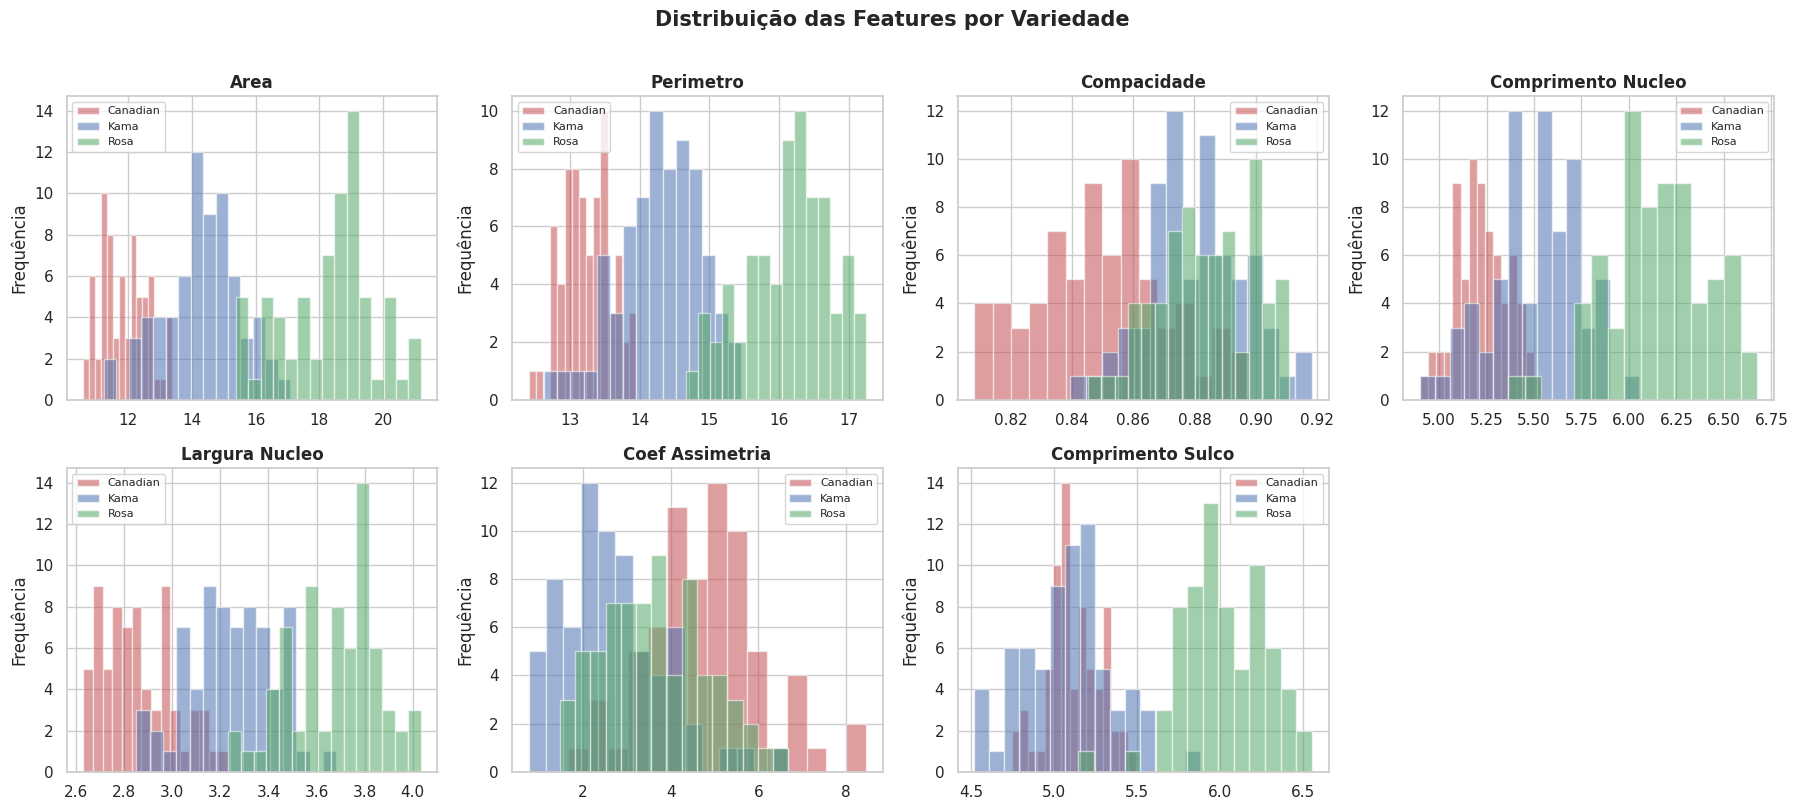

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
cores = {'Kama': '#4C72B0', 'Rosa': '#55A868', 'Canadian': '#C44E52'}

for i, col in enumerate(features):
    for variedade, grupo in df.groupby('variedade_nome'):
        axes[i].hist(
            grupo[col], alpha=0.55, bins=15,
            label=variedade, color=cores[variedade], edgecolor='white'
        )
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Distribuição das Features por Variedade', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.5 Boxplots por Variedade

Os boxplots complementam os histogramas com informação estrutural: mediana (linha central), intervalo interquartil (caixa), e outliers (pontos fora dos bigodes). São especialmente úteis para comparar a posição central de cada variedade em cada feature.


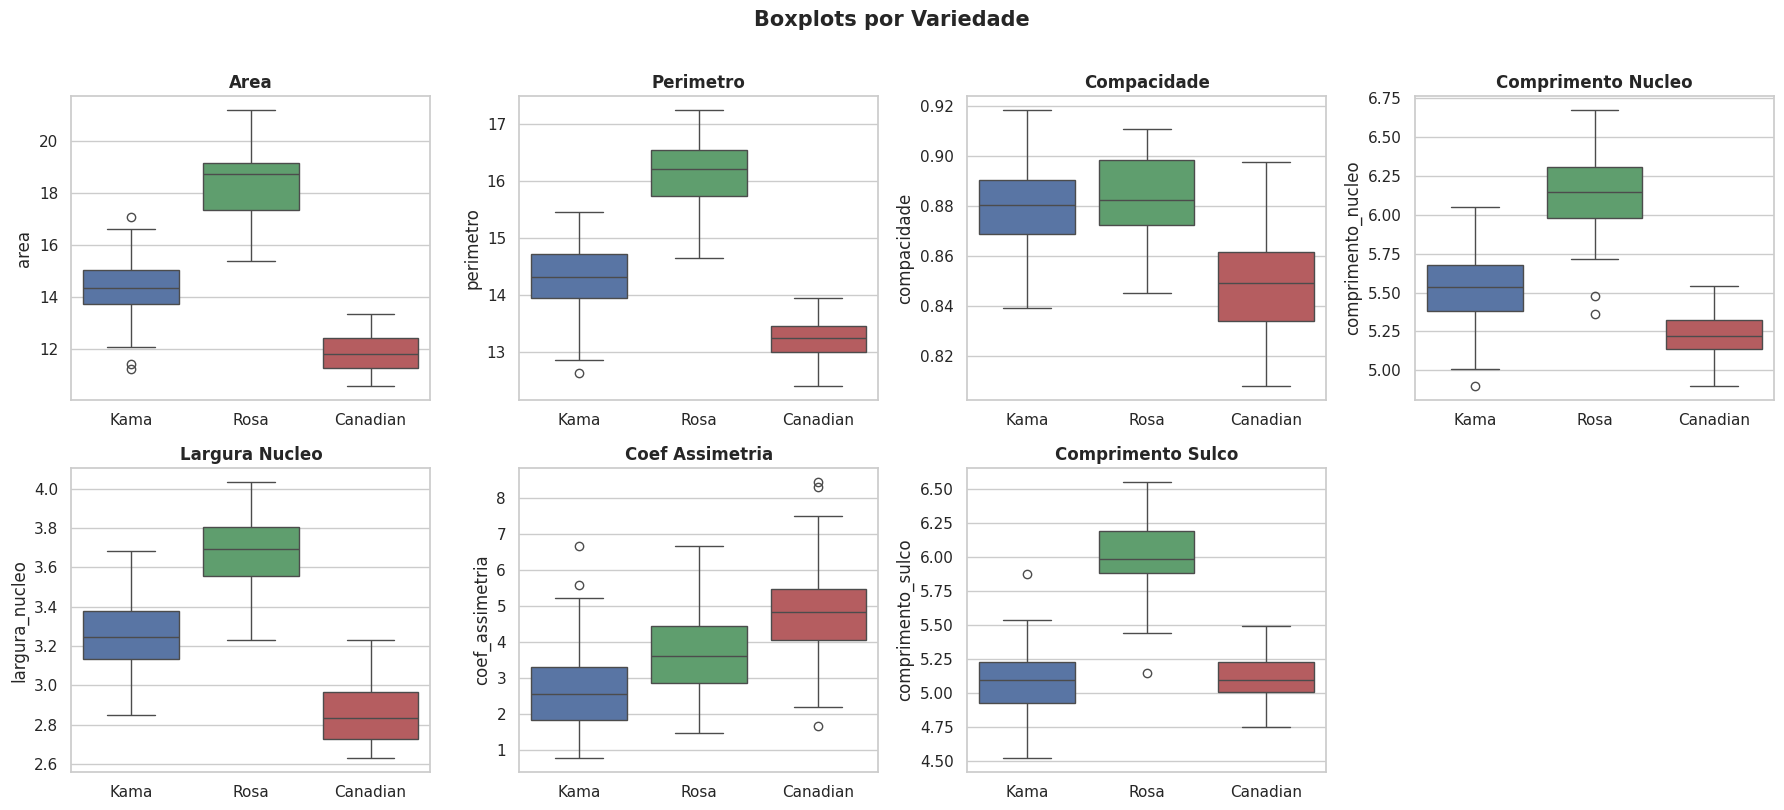

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(
        data=df, x='variedade_nome', y=col,
        ax=axes[i], palette=cores, order=['Kama', 'Rosa', 'Canadian']
    )
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
fig.suptitle('Boxplots por Variedade', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.6 Matriz de Correlação

A matriz de correlação de Pearson mede a relação linear entre pares de features, variando de -1 (correlação negativa perfeita) a +1 (correlação positiva perfeita).

Correlações altas entre features indicam **redundância de informação**: `area` e `perimetro`, por exemplo, tendem a crescer juntos:

- Para modelos baseados em distância (KNN, SVM), features altamente correlacionadas podem introduzir viés, pois a mesma informação é contada múltiplas vezes no cálculo
- Em projetos mais avançados, seria possível reduzir dimensionalidade (PCA) para eliminar redundância. Neste trabalho, mantemos todas as features para preservar a interpretabilidade

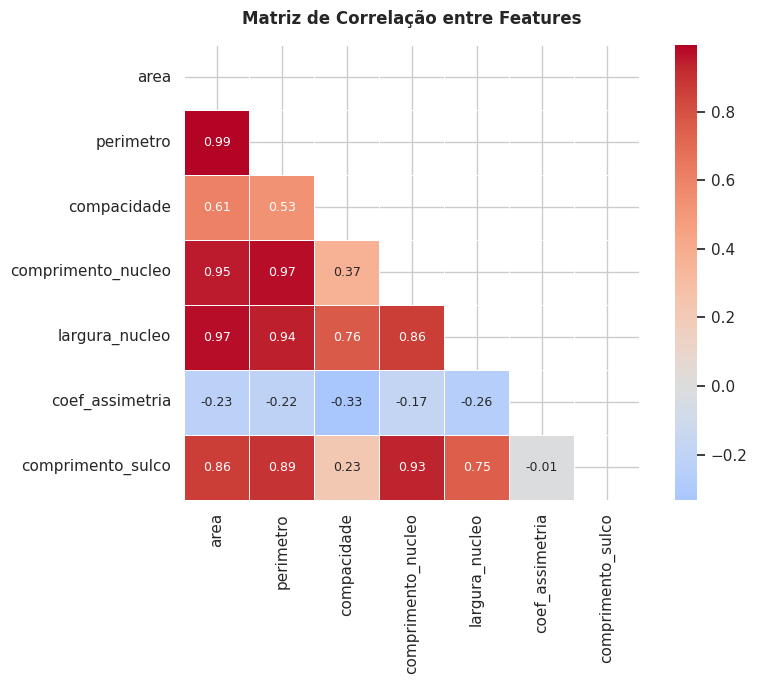

Top 3 pares mais correlacionados:
area       perimetro             0.994
perimetro  comprimento_nucleo    0.972
area       largura_nucleo        0.971
dtype: float64


In [ ]:
plt.figure(figsize=(9, 7))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, square=True,
    linewidths=0.5, annot_kws={'size': 9}
)
plt.title('Matriz de Correlação entre Features', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Par mais correlacionado
corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1].drop_duplicates().sort_values(ascending=False)
print('Top 3 pares mais correlacionados:')
print(corr_pairs.head(3).round(3))

### 1.7 Gráficos de Dispersão

Os gráficos de dispersão mostram como as variedades se distribuem no espaço de duas features simultaneamente. O objetivo é verificar **separabilidade**: se os pontos de classes diferentes formam grupos distintos, os algoritmos terão facilidade em aprender as fronteiras.

Escolhemos pares de features com correlação moderada para que cada eixo carregue informação diferente — pares muito correlacionados produziriam pontos alinhados numa diagonal, sem revelar separação entre classes.

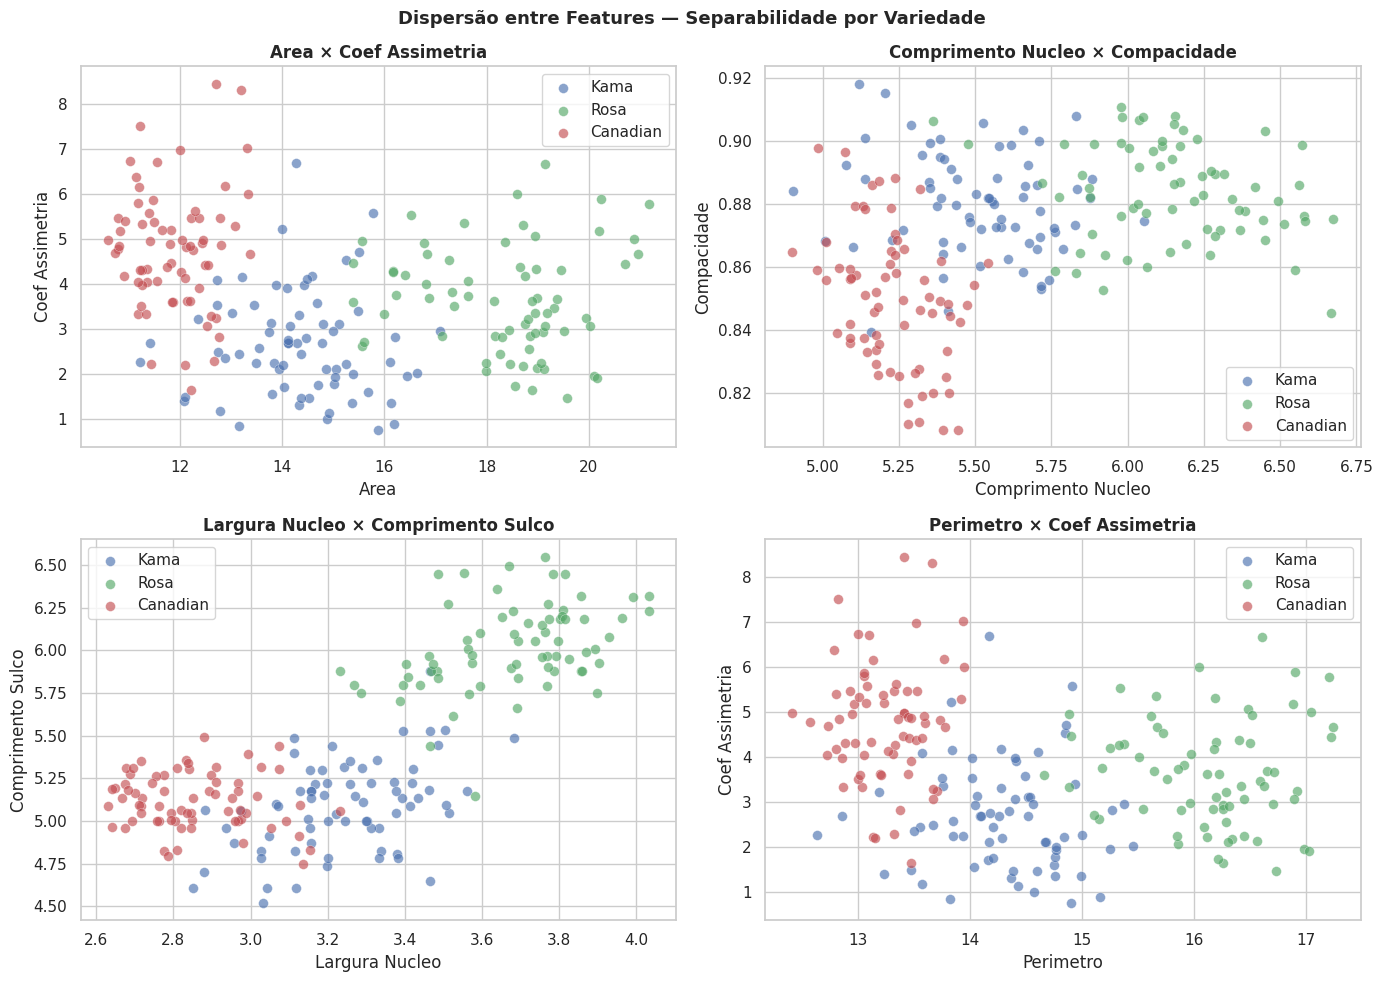

In [ ]:
pares = [
    ('area', 'coef_assimetria'),
    ('comprimento_nucleo', 'compacidade'),
    ('largura_nucleo', 'comprimento_sulco'),
    ('perimetro', 'coef_assimetria'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (x, y) in enumerate(pares):
    for variedade in ['Kama', 'Rosa', 'Canadian']:
        dados = df[df['variedade_nome'] == variedade]
        axes[i].scatter(
            dados[x], dados[y],
            label=variedade, alpha=0.65, s=50,
            color=cores[variedade], edgecolors='white', linewidth=0.3
        )
    axes[i].set_xlabel(x.replace('_', ' ').title())
    axes[i].set_ylabel(y.replace('_', ' ').title())
    axes[i].set_title(f'{x.replace("_", " ").title()} × {y.replace("_", " ").title()}', fontweight='bold')
    axes[i].legend()

fig.suptitle('Dispersão entre Features — Separabilidade por Variedade', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.8 Separação e Padronização dos Dados

#### Divisão treino/teste

O conjunto é dividido em 70% para treino e 30% para teste. O parâmetro `stratify=y` garante que a proporção de cada classe seja mantida nos dois subconjuntos — com 70 amostras por classe, isso resulta em 49 amostras de cada classe no treino e 21 no teste.

#### Padronização com StandardScaler

O `StandardScaler` transforma cada feature para ter **média 0 e desvio padrão 1**, aplicando: `x_novo = (x − média) / desvio_padrão`


In [ ]:
X = df[features].values
y = df['variedade'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Treino: {X_train_sc.shape[0]} amostras ({X_train_sc.shape[0]/len(X)*100:.0f}%)')
print(f'Teste:  {X_test_sc.shape[0]} amostras ({X_test_sc.shape[0]/len(X)*100:.0f}%)')
print(f'\nClasses no treino: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Classes no teste:  {dict(zip(*np.unique(y_test, return_counts=True)))}')
print('\n✅ Distribuição balanceada confirmada — stratify funcionou corretamente.')

Treino: 147 amostras (70%)
Teste:  63 amostras (30%)

Classes no treino: {np.int64(1): np.int64(49), np.int64(2): np.int64(49), np.int64(3): np.int64(49)}
Classes no teste:  {np.int64(1): np.int64(21), np.int64(2): np.int64(21), np.int64(3): np.int64(21)}

✅ Distribuição balanceada confirmada — stratify funcionou corretamente.


---
## 🤖 Fase 2 — Treinamento e Comparação de Modelos

Foram escolhidos quatro algoritmos com **filosofias de aprendizado distintas**, cobrindo as principais abordagens de classificação supervisionada:

| Algoritmo | Princípio | Sensível à escala? |
|---|---|---|
| KNN | Proximidade entre exemplos | Sim |
| SVM | Fronteira de máxima margem | Sim |
| Random Forest | Votação de árvores de decisão | Não |
| Regressão Logística | Combinação linear com probabilidade | Sim |


Todos os modelos recebem os **mesmos dados padronizados**.

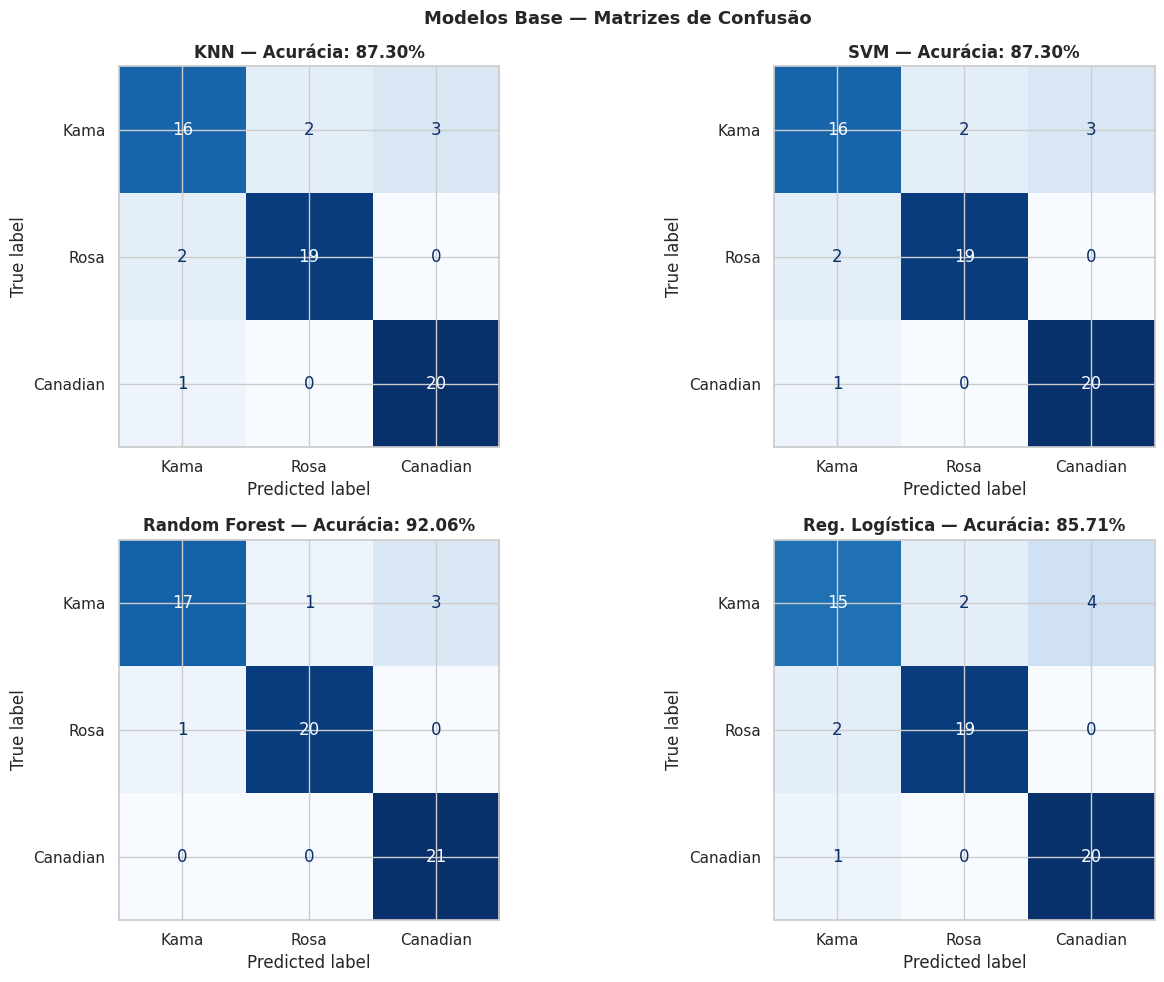

In [ ]:
nomes_classes = ['Kama', 'Rosa', 'Canadian']

modelos_base = {
    'KNN':                KNeighborsClassifier(),
    'SVM':                SVC(random_state=SEED),
    'Random Forest':      RandomForestClassifier(random_state=SEED),
    'Reg. Logística':     LogisticRegression(max_iter=1000, random_state=SEED),
}

resultados_base = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (nome, modelo) in enumerate(modelos_base.items()):
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    resultados_base[nome] = {
        'acuracia': acc,
        'relatorio': classification_report(y_test, y_pred, target_names=nomes_classes, output_dict=True)
    }
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=nomes_classes).plot(
        ax=axes[i], colorbar=False, cmap='Blues'
    )
    axes[i].set_title(f'{nome} — Acurácia: {acc:.2%}', fontweight='bold')

fig.suptitle('Modelos Base — Matrizes de Confusão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.1 Tabela Comparativa — Modelos Base

A matriz de confusão mostra **onde** cada modelo erra, não apenas quantos erros comete. Linhas representam a classe real; colunas, a classe prevista. Os valores na diagonal são acertos; fora dela, erros.

Todos os modelos erram mais na variedade **Kama**, que  apresenta maior sobreposição com Rosa nas features de forma (compacidade, comprimento do núcleo).

Usamos **F1-Score macro** como métrica principal por ser mais robusta que a acurácia simples: ela calcula o F1 para cada classe individualmente e tira a média, penalizando modelos que performam bem em algumas classes mas mal em outras.

In [ ]:
rows = []
for nome, res in resultados_base.items():
    rep = res['relatorio']
    rows.append({
        'Modelo': nome,
        'Acurácia': res['acuracia'],
        'Precisão (macro)': rep['macro avg']['precision'],
        'Recall (macro)':   rep['macro avg']['recall'],
        'F1-Score (macro)': rep['macro avg']['f1-score'],
    })

df_base = pd.DataFrame(rows).set_index('Modelo')
df_base.sort_values('F1-Score (macro)', ascending=False)\
    .style.format('{:.4f}')\
    .background_gradient(cmap='YlGn')

,Acurácia,Precisão (macro),Recall (macro),F1-Score (macro)
Modelo,,,,
Random Forest,0.9206,0.9239,0.9206,0.9192
KNN,0.8730,0.8721,0.8730,0.8713
SVM,0.8730,0.8721,0.8730,0.8713
Reg. Logística,0.8571,0.8571,0.8571,0.8543


---
## ⚙️ Fase 3 — Otimização com Grid Search

Os modelos da fase anterior usaram **hiperparâmetros padrão** — valores definidos pelos desenvolvedores das bibliotecas como ponto de partida razoável, mas não necessariamente os melhores para este problema específico.

O **Grid Search com validação cruzada** busca sistematicamente a melhor combinação de hiperparâmetros dentro de um espaço definido por nós.

In [ ]:
espacos = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11],
            'metric':      ['euclidean', 'manhattan'],
            'weights':     ['uniform', 'distance']
        }
        # 5 × 2 × 2 = 20 combinações × 5 folds = 100 treinamentos
    },
    'SVM': {
        'model': SVC(random_state=SEED),
        'params': {
            'C':      [0.1, 1, 10, 100],    # controle de regularização
            'kernel': ['rbf', 'linear'],     # forma da fronteira
            'gamma':  ['scale', 'auto']      # raio de influência (kernel rbf)
        }
        # 4 × 2 × 2 = 16 combinações × 5 folds = 80 treinamentos
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=SEED),
        'params': {
            'n_estimators':    [50, 100, 200],    # número de árvores
            'max_depth':       [None, 5, 10],     # profundidade máxima
            'min_samples_split': [2, 5]           # mínimo de amostras por divisão
        }
        # 3 × 3 × 2 = 18 combinações × 5 folds = 90 treinamentos
    },
    'Reg. Logística': {
        'model': LogisticRegression(max_iter=1000, random_state=SEED),
        'params': {
            'C':      [0.01, 0.1, 1, 10],      # regularização
            'solver': ['lbfgs', 'saga']         # algoritmo de otimização
        }
        # 4 × 2 = 8 combinações × 5 folds = 40 treinamentos
    }
}

melhores_modelos = {}
resultados_otim = {}

for nome, cfg in espacos.items():
    gs = GridSearchCV(
        cfg['model'], cfg['params'],
        cv=5,
        scoring='f1_macro',   # métrica mais robusta que acurácia para multiclasse
        n_jobs=-1
    )
    gs.fit(X_train_sc, y_train)
    melhores_modelos[nome] = gs.best_estimator_

    y_pred_opt = gs.best_estimator_.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred_opt)
    resultados_otim[nome] = {
        'acuracia': acc,
        'melhores_params': gs.best_params_,
        'relatorio': classification_report(y_test, y_pred_opt, target_names=nomes_classes, output_dict=True)
    }
    print(f'✅ {nome:<20} Acurácia: {acc:.2%} | Melhores params: {gs.best_params_}')

✅ KNN                  Acurácia: 88.89% | Melhores params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
✅ SVM                  Acurácia: 88.89% | Melhores params: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
✅ Random Forest        Acurácia: 88.89% | Melhores params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
✅ Reg. Logística       Acurácia: 88.89% | Melhores params: {'C': 10, 'solver': 'lbfgs'}


### 3.1 Antes vs Depois da Otimização

O gráfico compara a acurácia de cada modelo antes e após o Grid Search. Observamos que**a otimização não necessariamente melhora todos os modelos**, e pode até reduzir a performance no conjunto de teste se os hiperparâmetros encontrados causarem overfitting ou underfitting.

Isso acontece porque o Grid Search otimiza para a validação cruzada no treino. Com apenas 210 amostras, pequenas variações no conjunto de teste têm grande impacto nas métricas.

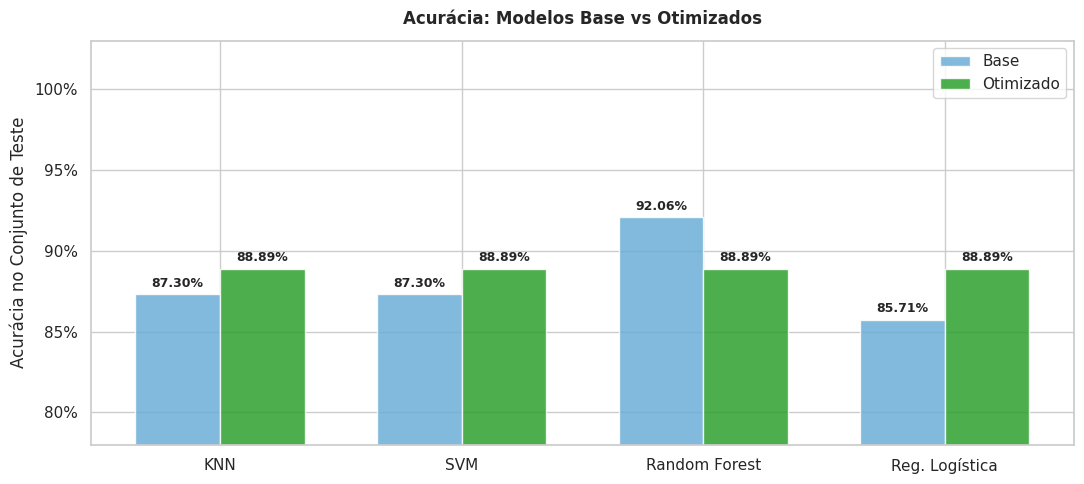

In [ ]:
nomes = list(modelos_base.keys())
acc_base = [resultados_base[n]['acuracia'] for n in nomes]
acc_otim = [resultados_otim[n]['acuracia'] for n in nomes]

x = np.arange(len(nomes))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - w/2, acc_base, w, label='Base',      color='#6baed6', alpha=0.85)
bars2 = ax.bar(x + w/2, acc_otim, w, label='Otimizado', color='#2ca02c', alpha=0.85)

for bar in [*bars1, *bars2]:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f'{bar.get_height():.2%}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_xticks(x)
ax.set_xticklabels(nomes)
ax.set_ylim(0.78, 1.03)
ax.set_ylabel('Acurácia no Conjunto de Teste')
ax.set_title('Acurácia: Modelos Base vs Otimizados', fontweight='bold', pad=12)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
plt.tight_layout()
plt.show()

### 3.2 Matrizes de Confusão — Modelos Otimizados

Com os modelos otimizados, examinamos novamente os perfis de erro. O padrão que emerge é consistente: **Kama é a variedade mais difícil de classificar** em todos os algoritmos, apresentando maior confusão com Rosa.

Canadian, por outro lado, é classificada corretamente pela maioria dos modelos, suas características físicas (grãos menores e com maior assimetria) são mais distintas.

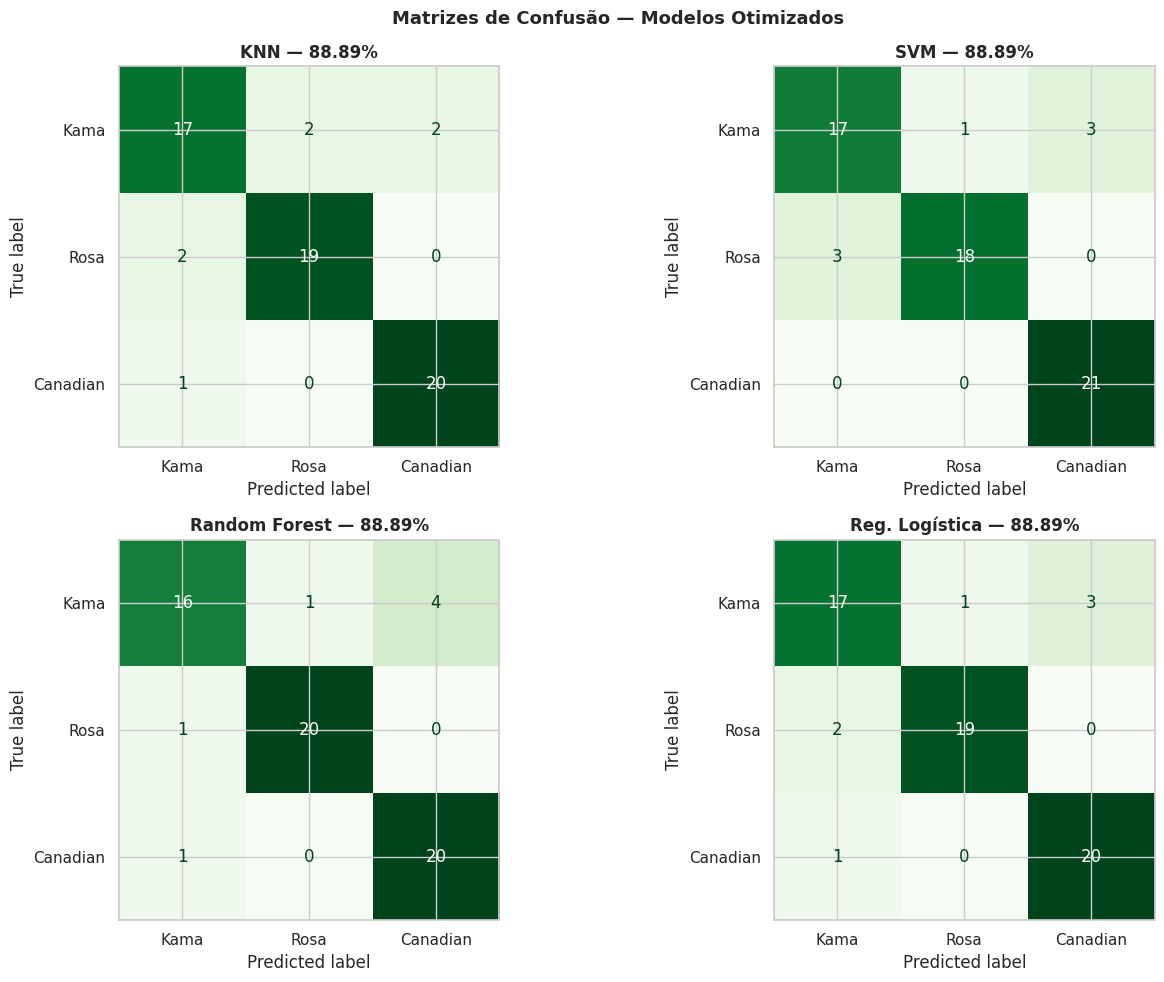

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, nome in enumerate(nomes):
    y_pred_opt = melhores_modelos[nome].predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred_opt)
    acc = resultados_otim[nome]['acuracia']
    ConfusionMatrixDisplay(cm, display_labels=nomes_classes).plot(
        ax=axes[i], colorbar=False, cmap='Greens'
    )
    axes[i].set_title(f'{nome} — {acc:.2%}', fontweight='bold')

fig.suptitle('Matrizes de Confusão — Modelos Otimizados', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔍 Fase 4 — Interpretação dos Resultados

### 4.1 Validação Cruzada — Estabilidade dos Modelos

Quando os modelos têm acurácias similares no conjunto de teste, a **estabilidade** passa a ser o critério de desempate mais importante.

A validação cruzada final é aplicada sobre os dados de treino dos modelos otimizados.

O **desvio padrão** dos 5 scores revela a sensibilidade de cada modelo à composição dos dados.

Em um dataset de apenas 210 amostras, a variância é naturalmente maior, sugerindo que modelos com desvio padrão alto precisam de mais dados para se estabilizar.

In [ ]:
print(f'{'Modelo':<22} {'CV Médio':>10} {'Desvio Padrão':>15} {'Scores por Fold'}')
print('─' * 75)

cv_data = {}
for nome, modelo in melhores_modelos.items():
    scores = cross_val_score(modelo, X_train_sc, y_train, cv=5, scoring='f1_macro')
    cv_data[nome] = scores
    scores_str = '  '.join([f'{s:.3f}' for s in scores])
    print(f'{nome:<22} {scores.mean():.4f}      ±{scores.std():.4f}        [{scores_str}]')

print()
melhor = max(cv_data, key=lambda n: cv_data[n].mean())
mais_estavel = min(cv_data, key=lambda n: cv_data[n].std())
print(f'Maior média:         {melhor}')
print(f'Mais estável (menor desvio): {mais_estavel}')

Modelo                   CV Médio   Desvio Padrão Scores por Fold
───────────────────────────────────────────────────────────────────────────
KNN                    0.9455      ±0.0346        [0.900  0.933  1.000  0.967  0.928]
SVM                    0.9730      ±0.0251        [0.967  0.933  1.000  1.000  0.965]
Random Forest          0.9057      ±0.0572        [0.866  0.833  1.000  0.900  0.930]
Reg. Logística         0.9592      ±0.0258        [0.967  0.967  1.000  0.933  0.930]

Maior média:         SVM
Mais estável (menor desvio): SVM


### 4.2 Importância das Features — Random Forest

O Random Forest, por ser um ensemble de árvores de decisão, registra internamente **quão frequentemente cada feature foi usada como critério de divisão** e **quanto essa divisão reduziu a impureza das classes**. A soma de todas as importâncias é 1.0.

Essa informação tem valor duplo: confirma os padrões observados na análise exploratória e aponta quais medições são mais relevantes para um sistema real. Em uma cooperativa, por exemplo, investir em sensores de alta precisão para as features mais importantes tem ROI maior.

**Importante**: importância de feature no Random Forest é uma estimativa relativa dentro do modelo. Não significa que as features menos importantes sejam inúteis — apenas que as árvores encontraram outras features mais discriminativas para as divisões que fizeram.

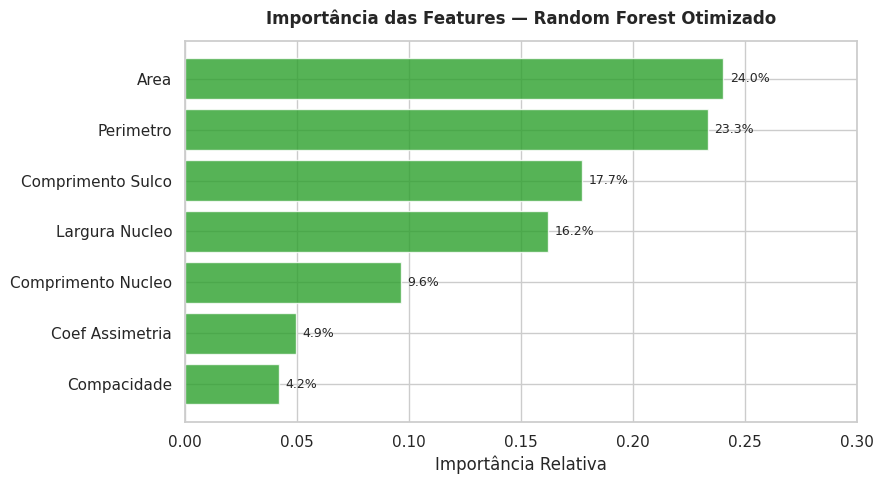

Feature mais importante:  Area (24.0%)
Feature menos importante: Compacidade (4.2%)

As 3 features mais importantes respondem por 65.1% da importância total.


In [ ]:
rf_best = melhores_modelos['Random Forest']
importancias = pd.Series(
    rf_best.feature_importances_,
    index=[f.replace('_', ' ').title() for f in features]
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importancias.index, importancias.values, color='#2ca02c', alpha=0.8, edgecolor='white')

for bar, val in zip(bars, importancias.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9)

ax.set_xlabel('Importância Relativa')
ax.set_title('Importância das Features — Random Forest Otimizado', fontweight='bold', pad=12)
ax.set_xlim(0, importancias.max() + 0.06)
plt.tight_layout()
plt.show()

print(f'Feature mais importante:  {importancias.idxmax()} ({importancias.max():.1%})')
print(f'Feature menos importante: {importancias.idxmin()} ({importancias.min():.1%})')
print(f'\nAs 3 features mais importantes respondem por {importancias.nlargest(3).sum():.1%} da importância total.')

### 4.3 Tabela Final Consolidada

A tabela final reúne todas as métricas relevantes para uma decisão fundamentada sobre qual modelo recomendar para implantação.

Além das métricas de performance, a coluna **Δ Melhoria** mostra o impacto real do Grid Search, permitindo avaliar se o custo computacional da otimização se justificou.

In [ ]:
rows_final = []
for nome in nomes:
    base = resultados_base[nome]
    otim = resultados_otim[nome]
    rep  = otim['relatorio']
    cv   = cv_data[nome]
    rows_final.append({
        'Modelo':          nome,
        'Acc Base':        base['acuracia'],
        'Acc Otimizado':   otim['acuracia'],
        'Δ':               otim['acuracia'] - base['acuracia'],
        'Precisão':        rep['macro avg']['precision'],
        'Recall':          rep['macro avg']['recall'],
        'F1-Score':        rep['macro avg']['f1-score'],
        'CV Médio':        cv.mean(),
        'CV Desvio':       cv.std(),
    })

df_final = pd.DataFrame(rows_final).set_index('Modelo')
df_final.sort_values('CV Médio', ascending=False)\
    .style\
    .format({
        'Acc Base': '{:.2%}', 'Acc Otimizado': '{:.2%}',
        'Δ': '{:+.2%}', 'Precisão': '{:.4f}',
        'Recall': '{:.4f}', 'F1-Score': '{:.4f}',
        'CV Médio': '{:.4f}', 'CV Desvio': '{:.4f}'
    })\
    .background_gradient(subset=['CV Médio', 'F1-Score'], cmap='YlGn')\
    .highlight_min(subset=['CV Desvio'], color='#d4edda')

,Acc Base,Acc Otimizado,Δ,Precisão,Recall,F1-Score,CV Médio,CV Desvio
Modelo,,,,,,,,
SVM,87.30%,88.89%,+1.59%,0.8908,0.8889,0.8875,0.9730,0.0251
Reg. Logística,85.71%,88.89%,+3.17%,0.8899,0.8889,0.8884,0.9592,0.0258
KNN,87.30%,88.89%,+1.59%,0.8880,0.8889,0.8881,0.9455,0.0346
Random Forest,92.06%,88.89%,-3.17%,0.8915,0.8889,0.8873,0.9057,0.0572


---
## 📝 Conclusão

### Sobre os dados

A análise exploratória revelou que as variedades de trigo são razoavelmente separáveis no espaço de features físicas, embora **Kama e Rosa compartilhem sobreposição** em várias dimensões, fato que se refletiu consistentemente nos erros de todos os modelos.

As features de maior poder discriminativo, confirmadas tanto pelos gráficos de dispersão quanto pela importância do Random Forest, foram **área**, **perímetro** e **comprimento do sulco**, que juntas respondem por aproximadamente 63% da importância total no modelo de florestas. A compacidade e o coeficiente de assimetria, apesar de fisicamente relevantes, contribuíram marginalmente — possivelmente por apresentarem maior sobreposição entre as classes ou por estarem correlacionadas com features mais informativas.

### Sobre os modelos

Todos os quatro algoritmos demonstraram competência no problema, com acurácias entre 86% e 92% nos modelos base e convergência para ~89% após otimização. Essa convergência é, em si, um resultado relevante: sugere que as fronteiras de decisão do problema são bem definidas o suficiente para que abordagens distintas cheguem a resultados similares.

A validação cruzada, no entanto, revelou diferenças significativas de estabilidade que a acurácia no teste não capturava:

- **SVM** apresentou o maior CV médio (97%) com desvio padrão moderado (2.5%), sendo o melhor balanço entre performance e consistência
- **Regressão Logística** ficou próxima (~96%) com desvio padrão similar
- **Random Forest** demonstrou a maior instabilidade (desvio ~5.7%), com variação de quase 17 pontos percentuais entre o melhor e o pior fold
- **KNN** ocupou posição intermediária, com sensibilidade ao tamanho reduzido do dataset

### Sobre a otimização

O Grid Search produziu ganhos modestos em alguns casos, a acurácia no teste até reduziu levemente após a otimização. Isso ilustra um ponto essencial: **otimizar para a validação cruzada não garante melhoria no conjunto de teste**, especialmente em datasets pequenos onde a variância amostral é alta. O resultado mais expressivo da otimização foi encontrar hiperparâmetros mais adequados à estrutura do problema, como o uso de distância Manhattan no KNN e kernel linear no SVM, sugerindo que as fronteiras entre classes são aproximadamente lineares no espaço padronizado.

### Recomendação

Para implantação em um sistema real de classificação agrícola, a recomendação é o **SVM com kernel linear** (otimizado), pelos seguintes motivos:

1. **Maior estabilidade na validação cruzada** (~97% com desvio de 2.5%): o critério mais confiável com amostras limitadas
2. **Performance no teste comparável aos demais**: após otimização
3. **Robustez a outliers**: a margem de separação máxima é menos sensível a pontos extremos do que o KNN, que depende de todos os vizinhos
4. **Escalabilidade**: ao contrário do KNN, o SVM não precisa armazenar todos os exemplos de treino para fazer previsões



